# Chain using LangGraph

In this section, we will see how we can build a simple chain using LangGraph that uses 4 important concepts:

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute tool calls in our graph nodes

In [2]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

## How to Use Chat Messages as Our Graph State

We can use messages which can be used to capture different roles within a conversation.

LangChain has various message types including `HumanMessage`, `AIMessage`, `SystemMessage` and `ToolMessage`.

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components:

- `content` - Content of the message
- `name` - Specify the name of author
- `response_metadata` - Optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help?", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding.", name="Dev"))
messages.append(AIMessage(content=f"Which programming language you want to learn?", name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language.", name="Dev"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help?
================================ Human Message =================================
Name: Dev

I want to learn coding.
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn?
================================ Human Message =================================
Name: Dev

I want to learn python programming language.


## How to Use Chat Models in Graph Nodes

Chat models allow us to send a sequence of messages to an LLM and receive a response.

- We can pass `HumanMessage`, `AIMessage`, and other message types as input to the chat model.
- The chat model processes the complete message sequence to understand the conversation context.
- The model returns an `AIMessage` containing the generated response.
- We can access the generated response using the `.content` attribute.
- We can also access additional information about the response using `.response_metadata`.

In [4]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
result=llm.invoke(messages)

In [5]:
result

AIMessage(content='## 🎯 Your Roadmap to Learning Python\n\nBelow is a **step‑by‑step learning plan** you can follow at your own pace. It’s broken into **milestones**, each with:\n\n1. **What to learn** (core concepts & skills)  \n2. **Quick‑start resources** (free tutorials, videos, docs)  \n3. **Hands‑on practice** (exercises, mini‑projects)  \n4. **Checkpoint quiz** (to test you before moving on)\n\nFeel free to jump around, but most beginners find the linear path works best.\n\n---\n\n## 📅 Milestone 1 – Foundations (1‑2 weeks)\n\n| Goal | Topics | Resources | Practice |\n|------|--------|-----------|----------|\n| **Set up your environment** | Installing Python, using VS\u202fCode or PyCharm, running scripts, REPL | • Official installer: <https://python.org/downloads> <br>• VS\u202fCode Python extension tutorial (YouTube, 10\u202fmin) | Run `python --version`, open a terminal, write `print("Hello, world!")` |\n| **Basic syntax & data types** | Variables, numbers, strings, booleans, 

In [6]:
result.content

'## 🎯 Your Roadmap to Learning Python\n\nBelow is a **step‑by‑step learning plan** you can follow at your own pace. It’s broken into **milestones**, each with:\n\n1. **What to learn** (core concepts & skills)  \n2. **Quick‑start resources** (free tutorials, videos, docs)  \n3. **Hands‑on practice** (exercises, mini‑projects)  \n4. **Checkpoint quiz** (to test you before moving on)\n\nFeel free to jump around, but most beginners find the linear path works best.\n\n---\n\n## 📅 Milestone 1 – Foundations (1‑2 weeks)\n\n| Goal | Topics | Resources | Practice |\n|------|--------|-----------|----------|\n| **Set up your environment** | Installing Python, using VS\u202fCode or PyCharm, running scripts, REPL | • Official installer: <https://python.org/downloads> <br>• VS\u202fCode Python extension tutorial (YouTube, 10\u202fmin) | Run `python --version`, open a terminal, write `print("Hello, world!")` |\n| **Basic syntax & data types** | Variables, numbers, strings, booleans, basic operators, `

In [7]:
result.response_metadata

{'token_usage': {'completion_tokens': 2984,
  'prompt_tokens': 117,
  'total_tokens': 3101,
  'completion_time': 6.215799008,
  'completion_tokens_details': {'reasoning_tokens': 26},
  'prompt_time': 0.004590881,
  'prompt_tokens_details': None,
  'queue_time': 0.394495083,
  'total_time': 6.220389889},
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': 'fp_8655ddce88',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

## How to Bind Tools to Our LLM in Chat Models

Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema

### Defining a Tool

In [8]:
def add(a:int, b:int) -> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

### Chat Model

In [9]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FF85E0CC50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FF85BA2150>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Binding Tool with LLM

In [ ]:
llm_with_tools=llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2?", name="Dev")])

### Viewing the Tool Call

In [14]:
tool_call

AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks: "What is 2 plus 2?" It\'s a simple arithmetic. The answer is 4. No need to use function. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 149, 'total_tokens': 202, 'completion_time': 0.110449323, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.063577651, 'prompt_tokens_details': None, 'queue_time': 0.33733971, 'total_time': 0.174026974}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_77b12279f9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ebea-fa23-7fe2-9cc6-23c18446f5cb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 149, 'output_tokens': 53, 'total_tokens': 202, 'output_token_details': {'reasoning': 34}})

### Viewing Tool Calls

In [15]:
tool_call.tool_calls

[]

## How to Execute Tool Calls in Our Graph Nodes

### Using Messages as State

In [ ]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

### Reducers

Reducers define how updates to a state key should be handled when multiple nodes modify the same state.

- By default, a new state value **overrides** the previous value.
- For messages, we often want to **append** new messages instead of replacing the existing ones.
- LangGraph provides a built-in `add_messages` reducer for this purpose.
- The `add_messages` reducer appends new messages to the existing list of messages.
- We can apply the reducer by annotating the `messages` state key with `add_messages`.

### Defining the State with add_messages

In [31]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

### Reducers with add_messages

In [32]:
initial_messages=[AIMessage(content=f"Please tell me how can I help?",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding.",name="Dev"))
initial_messages

[AIMessage(content='Please tell me how can I help?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding.', additional_kwargs={}, response_metadata={}, name='Dev')]

### Creating an AI Message

In [33]:
ai_message=AIMessage(content=f"Which programming language you want to learn?",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

### Using add_messages to Append Messages

In [34]:
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I help?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='8c87e511-d49d-4093-ba9e-5748f84195a5', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding.', additional_kwargs={}, response_metadata={}, name='Dev', id='72ddaae0-20c2-4bc7-8f4a-6c3ec149ecbd'),
 AIMessage(content='Which programming language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='bd20f178-f4fe-4533-8d06-6c702a43b0f6', tool_calls=[], invalid_tool_calls=[])]

Reducers add_messages is used to append instead of override

### Chatbot Node Functionality

In [35]:
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### Building the LangGraph

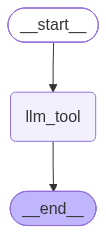

In [36]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

### Creating the StateGraph
builder=StateGraph(State)

### Adding the Node
builder.add_node("llm_tool", llm_tool)

### Adding the Edges
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

### Compiling the Graph
graph=builder.compile()

### Displaying the Graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoking the Graph Without a Tool Call

In [46]:
messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 + 2 = 4.


### Invoking the Graph With a Tool Call

In [47]:
messages = graph.invoke({
    "messages": [
        HumanMessage(
            content="Use the add tool to calculate 2 + 2."
        )
    ]
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Use the add tool to calculate 2 + 2.
================================== Ai Message ==================================
Tool Calls:
  add (fc_d7404379-618d-4793-8ac2-206fc98107a4)
 Call ID: fc_d7404379-618d-4793-8ac2-206fc98107a4
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


### Defining the Tools

In [38]:
tools=[add]

### Building the LangGraph

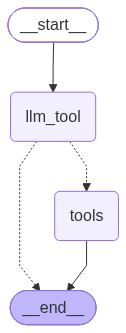

In [ ]:
### Importing ToolNode and tools_condition
from langgraph.prebuilt import ToolNode, tools_condition

### Creating the StateGraph
builder=StateGraph(State)

### Adding the Node
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

### Adding the Edges
builder.add_edge(START, "llm_tool")

# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges("llm_tool", tools_condition)

builder.add_edge("tools", END)

### Compiling the Graph
graph=builder.compile()

### Displaying the Graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoking the Graph Without a Tool Call

In [48]:
messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 + 2 = 4.


### Invoking the Graph With a Tool Call

In [49]:
messages = graph.invoke({
    "messages": [
        HumanMessage(
            content="Use the add tool to calculate 2 + 2."
        )
    ]
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Use the add tool to calculate 2 + 2.
================================== Ai Message ==================================
Tool Calls:
  add (fc_cb21590a-ac01-4889-9117-74e17a145f3b)
 Call ID: fc_cb21590a-ac01-4889-9117-74e17a145f3b
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


### Invoking the Graph Without a Tool Call

In [50]:
messages=graph.invoke({"messages":"Tell me about Iron Man in short"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me about Iron Man in short
================================== Ai Message ==================================

**Iron Man** (Tony Stark) is a Marvel Comics superhero who first appeared in *Tales of Suspense* #39 (1963). A brilliant engineer and billionaire industrialist, Tony builds a powered exoskeleton suit after being captured by terrorists. The suit grants him super‑human strength, flight, advanced weaponry, and a variety of high‑tech gadgets. As Iron Man, he leads the Avengers, fights global threats, and grapples with personal issues like alcoholism, ego, and the responsibility that comes with his technology. The character is famously portrayed by Robert Downey Jr. in the Marvel Cinematic Universe (2008‑2023).


### Invoking the Graph With a Tool Call

In [51]:
messages = graph.invoke({
    "messages": [
        HumanMessage(
            content="Tell me about Iron Man in short"
        )
    ]
})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me about Iron Man in short
================================== Ai Message ==================================

**Iron Man** (Tony Stark) is a Marvel Comics superhero who first appeared in *Tales of Suspense* #39 (1963). A billionaire genius, industrialist, and playboy, Stark builds a powered armor suit after being captured by terrorists. The suit gives him superhuman strength, flight, advanced weaponry, and an AI assistant (often JARVIS). Using his intellect and resources, he becomes a founding member of the Avengers, fighting threats both earthly and cosmic while grappling with his own personal demons and the responsibilities of his technology.
